# 02 — Baseline Results

Phase 2 du plan de cadrage : entraîner une baseline U-Net sur la frame annotée (pas de contexte temporel), calculer Dice/IoU/Precision/Recall sur le split validation, et comparer deux architectures :

- **`unet_scratch`** : U-Net léger implémenté from scratch, sans poids pré-entraînés.
- **`unet_resnet34`** : U-Net avec encodeur ResNet34 pré-entraîné ImageNet (`segmentation-models-pytorch`).

Entrée : représentation **Ash RGB** (bandes 11/13/14/15), construite en Phase 1. Données : mini-échantillon OpenContrails (6 records train, 6 validation) — utile pour valider le pipeline de bout en bout, **pas** pour obtenir un score représentatif (voir bilan en fin de notebook).

In [1]:
import json
import sys
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import torch


def find_project_root(start: Path) -> Path:
    markers = ("requirements.txt", ".git")
    start = start.resolve()
    for candidate in (start, *start.parents):
        if any((candidate / marker).exists() for marker in markers):
            return candidate
    fallback = start / "Contrail-detection"
    if any((fallback / marker).exists() for marker in markers):
        return fallback
    raise FileNotFoundError(f"Racine du projet introuvable à partir de {start}")


PROJECT_ROOT = find_project_root(Path.cwd())
sys.path.insert(0, str(PROJECT_ROOT))

from src.data.dataset import ContrailAshRGBDataset  # noqa: E402
from src.models.factory import build_model  # noqa: E402

print("Project root :", PROJECT_ROOT)

Project root : C:\Users\roche\Contrail-detection


In [2]:
EXPERIMENTS = ["baseline_unet_scratch", "baseline_unet_resnet34"]

results = {}
for exp_name in EXPERIMENTS:
    with open(PROJECT_ROOT / "reports" / exp_name / "metrics.json", encoding="utf-8") as f:
        results[exp_name] = json.load(f)

for exp_name, r in results.items():
    print(f"{exp_name}: best_epoch={r['best_epoch']}, best_val_dice={r['best_val_dice']:.4f}")

baseline_unet_scratch: best_epoch=8, best_val_dice=0.8333
baseline_unet_resnet34: best_epoch=56, best_val_dice=0.3333


## Configuration des expériences

Chaque expérience a un objectif, une configuration enregistrée (`configs/*.yaml`) et des métriques sauvegardées (`reports/<nom>/metrics.json`) — pas de run "pour voir".

In [3]:
config_df = pd.DataFrame({exp_name: r["config"] for exp_name, r in results.items()})
config_df

,baseline_unet_scratch,baseline_unet_resnet34
name,baseline_unet_scratch,baseline_unet_resnet34
model,unet_scratch,unet_resnet34
in_channels,3,3
seed,42,42
epochs,60,60
batch_size,2,2
lr,0.001,0.0001
dice_weight,0.5,0.5
threshold,0.5,0.5
data_dir,Data/Raw/opencontrails_mini_sample,Data/Raw/opencontrails_mini_sample


## Courbes d'apprentissage

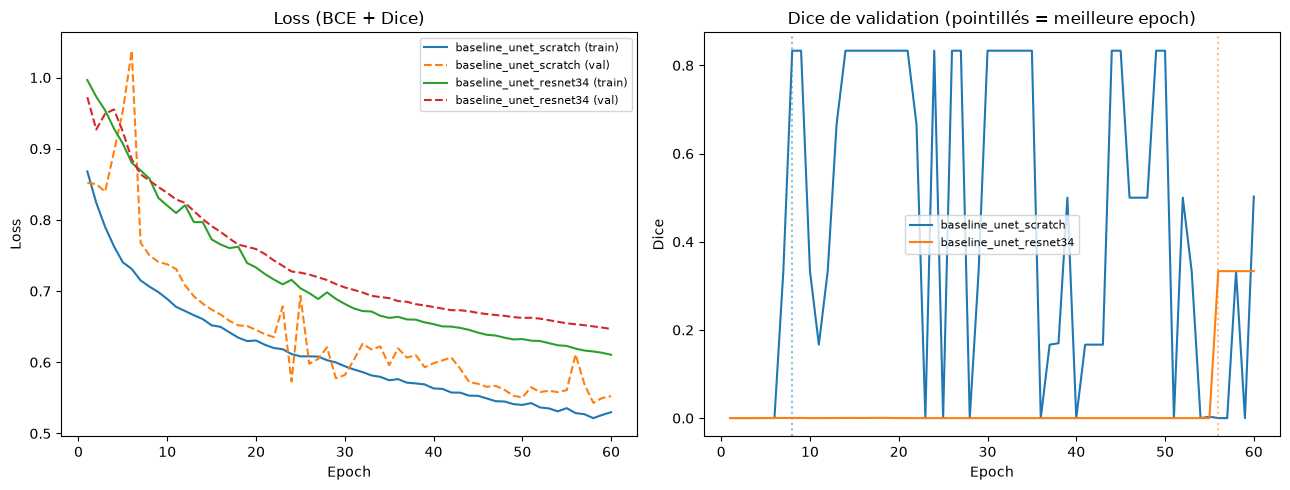

In [4]:
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

for exp_name, r in results.items():
    hist_df = pd.DataFrame(r["history"])
    axes[0].plot(hist_df["epoch"], hist_df["train_loss"], label=f"{exp_name} (train)")
    axes[0].plot(hist_df["epoch"], hist_df["val_loss"], label=f"{exp_name} (val)", linestyle="--")
    axes[1].plot(hist_df["epoch"], hist_df["val_dice"], label=exp_name)
    axes[1].axvline(r["best_epoch"], color=axes[1].lines[-1].get_color(), linestyle=":", alpha=0.5)

axes[0].set_title("Loss (BCE + Dice)")
axes[0].set_xlabel("Epoch")
axes[0].set_ylabel("Loss")
axes[0].legend(fontsize=8)

axes[1].set_title("Dice de validation (pointillés = meilleure epoch)")
axes[1].set_xlabel("Epoch")
axes[1].set_ylabel("Dice")
axes[1].legend(fontsize=8)

plt.tight_layout()
plt.show()

## Métriques finales (meilleur checkpoint, split validation)

In [5]:
final_metrics_df = pd.DataFrame({exp_name: r["final_val_metrics"] for exp_name, r in results.items()}).T
final_metrics_df

,dice,iou,precision,recall
baseline_unet_scratch,0.833333,0.833333,0.833333,0.833333
baseline_unet_resnet34,0.333333,0.333333,0.333333,0.333333


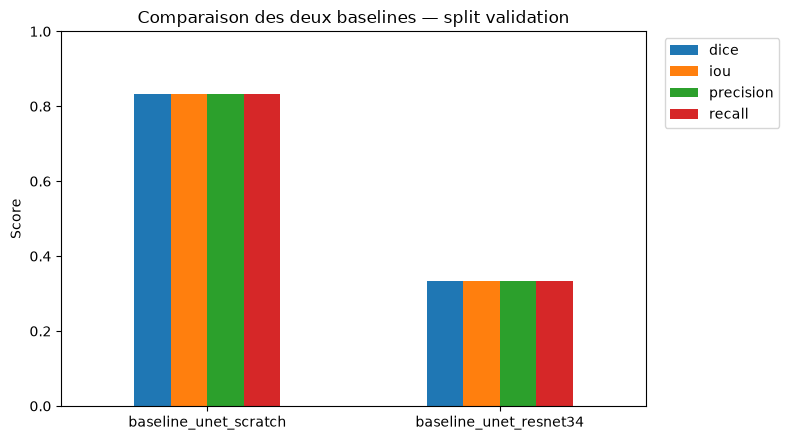

In [6]:
final_metrics_df.plot(kind="bar", figsize=(8, 4.5), ylim=(0, 1))
plt.title("Comparaison des deux baselines — split validation")
plt.ylabel("Score")
plt.xticks(rotation=0)
plt.legend(title=None, bbox_to_anchor=(1.02, 1), loc="upper left")
plt.tight_layout()
plt.show()

### Détail par record (validation)

Utile pour repérer si un modèle échoue sur les mêmes records que l'autre — un premier pas vers l'analyse d'erreurs de la Phase 5.

In [7]:
per_record_frames = []
for exp_name, r in results.items():
    df = pd.DataFrame(r["final_val_per_record"])
    df["experiment"] = exp_name
    per_record_frames.append(df)

per_record_df = pd.concat(per_record_frames, ignore_index=True)
per_record_df.pivot(index="record_id", columns="experiment", values="dice")

experiment,baseline_unet_resnet34,baseline_unet_scratch
record_id,,
1000834164244036115,0.0,1.0
1002653297254493116,1.0,1.0
1002777035567823518,0.0,0.0
1010397530434035516,0.0,1.0
1012978360687713914,0.0,1.0
1013721207578258217,1.0,1.0


## Visualisation qualitative des prédictions

On recharge le meilleur checkpoint de chaque modèle et on affiche, pour quelques records de validation, l'entrée Ash RGB, le masque agrégé et la prédiction de chaque modèle (seuillée à 0.5).

C:\Users\roche\Contrail-detection\.venv\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


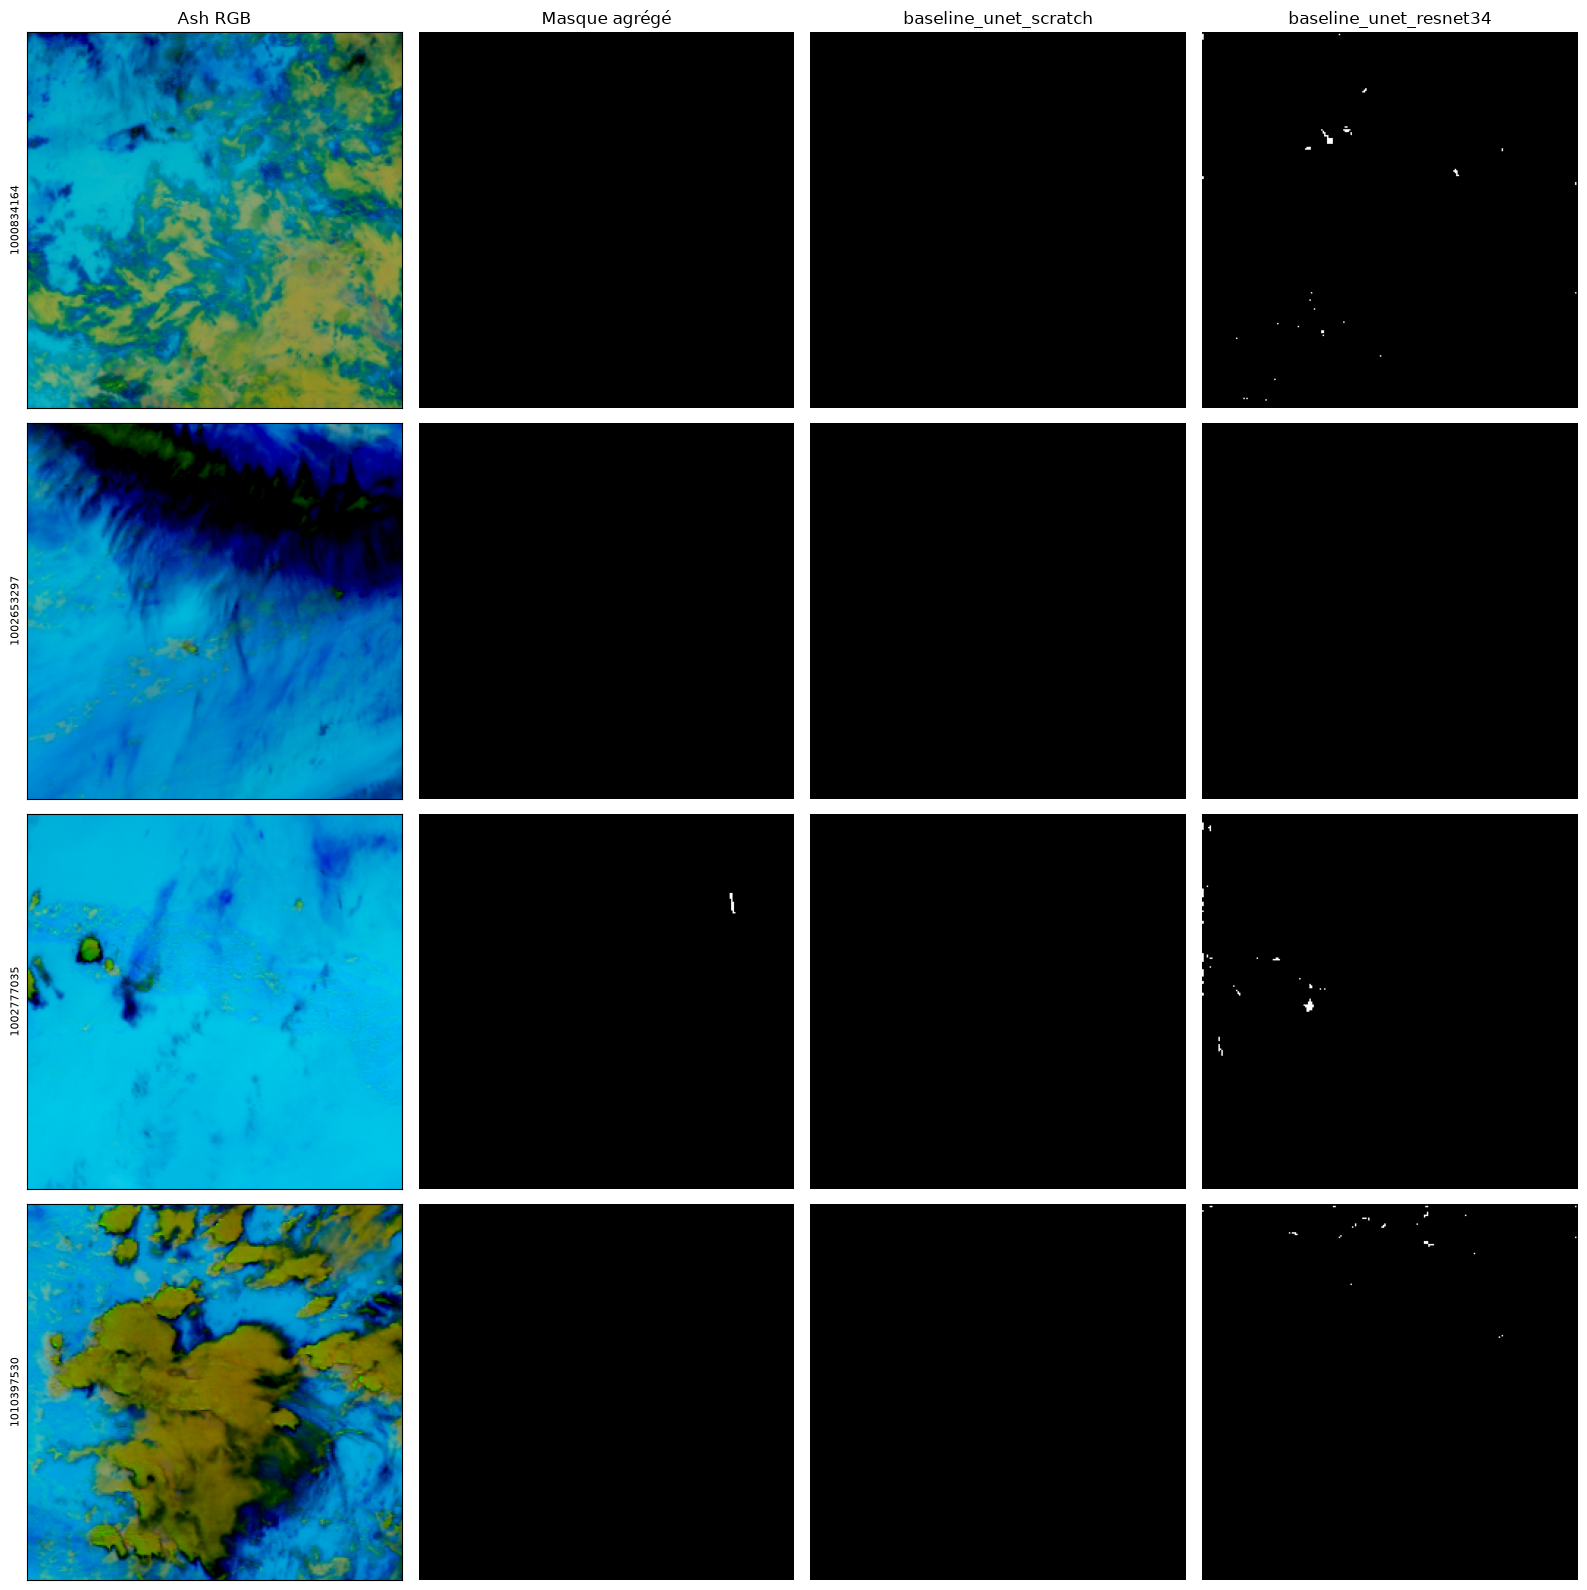

In [8]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")

val_ds = ContrailAshRGBDataset(PROJECT_ROOT / "Data" / "Raw" / "opencontrails_mini_sample" / "validation")

loaded_models = {}
for exp_name, r in results.items():
    model = build_model(r["config"]["model"], in_channels=r["config"].get("in_channels", 3))
    model.load_state_dict(torch.load(r["checkpoint_path"], map_location=device))
    model.eval().to(device)
    loaded_models[exp_name] = model

n_show = min(4, len(val_ds))
fig, axes = plt.subplots(n_show, 2 + len(loaded_models), figsize=(4 * (2 + len(loaded_models)), 4 * n_show))

for row in range(n_show):
    image, mask, record_id = val_ds[row]

    axes[row, 0].imshow(image.permute(1, 2, 0).numpy())
    axes[row, 0].set_title("Ash RGB" if row == 0 else "")
    axes[row, 0].set_ylabel(record_id[:10], fontsize=8)
    axes[row, 0].set_xticks([])
    axes[row, 0].set_yticks([])

    axes[row, 1].imshow(mask.squeeze(0).numpy(), cmap="gray")
    axes[row, 1].set_title("Masque agrégé" if row == 0 else "")
    axes[row, 1].axis("off")

    for col, (exp_name, model) in enumerate(loaded_models.items(), start=2):
        with torch.no_grad():
            prob = torch.sigmoid(model(image.unsqueeze(0).to(device)))[0, 0].cpu().numpy()
        axes[row, col].imshow(prob >= 0.5, cmap="gray")
        axes[row, col].set_title(exp_name if row == 0 else "")
        axes[row, col].axis("off")

plt.tight_layout()
plt.show()

## Bilan de la Phase 2

- **Pipeline de bout en bout validé** : chargement des records → Ash RGB → U-Net → loss BCE+Dice → métriques Dice/IoU/Precision/Recall sur validation → checkpoint du meilleur modèle → figures. C'était le critère de réussite du premier jalon du dossier de cadrage.
- **Deux architectures comparées** dans les mêmes conditions (seed, split, loss, seuil) : `unet_scratch` (Dice val moyen = 0.833) et `unet_resnet34` (Dice val moyen = 0.333).

### Le Dice moyen est trompeur ici — à lire avec le détail par record

Sur les 6 records de validation, **5 n'ont aucun pixel positif** et le 6ᵉ (`1002777035567823518`) n'en a que 0.04 %. Résultat :

- `unet_scratch` obtient Dice = 1.0 sur les 5 records vides (il prédit "pas de contrail" partout) et **Dice = 0.0 sur l'unique record avec un vrai contrail**. Son score moyen de 0.833 ne reflète donc aucune capacité de détection réelle — c'est un détecteur qui ne détecte rien.
- `unet_resnet34` obtient Dice = 0.0 sur 4 records (dont, à nouveau, le seul record positif) et Dice = 1.0 sur seulement 2 des records vides : il produit apparemment des faux positifs sur certains records vides, sans doute parce que le décodeur (non pré-entraîné) n'a pas eu le temps de converger en 60 epochs avec seulement 6 images d'entraînement et un lr faible (1e-4) adapté à l'encodeur pré-entraîné.

**Conclusion honnête : aucun des deux modèles ne détecte de contrail à ce stade.** Ce n'est pas surprenant ni inquiétant — le mini-échantillon ne contient que 3 records avec contrails côté train et 1 seul côté validation, ce qui est insuffisant pour apprendre quoi que ce soit de généralisable. Le pipeline fonctionne correctement ; c'est la quantité de données qui manque, exactement comme prévu par le dossier de cadrage (« ne pas tirer de conclusion scientifique sur le mini-échantillon »).

- **Reproductibilité** : chaque run a une config versionnée (`configs/*.yaml`), un seed fixé, et des métriques sauvegardées (`reports/<nom>/metrics.json`), y compris le détail par record qui a permis ce diagnostic. Les checkpoints (`checkpoints/`) sont volontairement ignorés par Git.

### Prochaine étape

Passer à un sous-ensemble beaucoup plus grand de OpenContrails (Kaggle/cloud) avec plusieurs dizaines/centaines de records positifs, en gardant exactement le même pipeline. Ensuite seulement, Phase 3 (contexte temporel) et Phase 4 (contribution originale) auront un sens — et le Dice moyen redeviendra une métrique interprétable.